<div style="background:linear-gradient(135deg,#3b0764 0%,#7e22ce 55%,#a855f7 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#e9d5ff;font-weight:700;text-transform:uppercase">Chapter 91 · Correlation &amp; Association</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Correlation vs. Causation ⚠️</div>
  <div style="font-size:15px;color:#faf5ff;max-width:740px;line-height:1.6">The most important caveat in statistics: a correlation has four explanations and only one is causation. We separate confounding, reverse causation, and coincidence, use partial correlation to expose a lurking variable, and debunk the classic ice-cream-and-drownings link.</div>
  <div style="margin-top:16px;font-size:13px;color:#e9d5ff">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, regplots, pairplots)
import statsmodels.api as sm
from statsmodels.formula.api import ols
PUR="#9333ea"; DEEP="#7e22ce"; LIGHT="#c084fc"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"; BLUE="#2563eb"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(91)

<div style="background:#faf5ff;border-left:5px solid #9333ea;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7e22ce;letter-spacing:1px">DEMO 1 · FOUR REASONS TWO THINGS CORRELATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Only one of them is 'x causes y'</div>
<div style="color:#4a5578;margin-top:6px">A correlation between x and y has four possible explanations: x causes y, y causes x (reverse), a third variable z causes both (confounding), or pure coincidence. The data alone cannot tell them apart, which is why correlation is not causation.</div>
</div>

In [2]:
print("x ~ y observed. Possible stories:")
print("  1) x -> y        (x causes y)")
print("  2) y -> x        (REVERSE causation)")
print("  3) z -> x, z -> y (CONFOUNDING: a lurking common cause)")
print("  4) coincidence    (spurious, especially with many comparisons)")
print("\nThe correlation number is identical in all four; only DESIGN or domain knowledge decides.")

x ~ y observed. Possible stories:
  1) x -> y        (x causes y)
  2) y -> x        (REVERSE causation)
  3) z -> x, z -> y (CONFOUNDING: a lurking common cause)
  4) coincidence    (spurious, especially with many comparisons)

The correlation number is identical in all four; only DESIGN or domain knowledge decides.


This is the single most important caveat in statistics. A strong r is evidence that two variables are <em>associated</em>, never proof that one <em>causes</em> the other. The rest of the chapter is about telling the four stories apart.

<div style="background:#faf5ff;border-left:5px solid #9333ea;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7e22ce;letter-spacing:1px">DEMO 2 · CONFOUNDING, AND HOW TO CATCH IT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A lurking variable manufactures a correlation</div>
<div style="color:#4a5578;margin-top:6px">The classic trap: z drives both x and y, so x and y correlate even though neither causes the other. We simulate it, then CONTROL for z with a partial correlation (correlate the residuals after regressing out z); the spurious link collapses.</div>
</div>

raw corr(x, y)           = 0.88   <- strong, but spurious
partial corr(x, y | z)   = -0.02   <- collapses once z is held constant


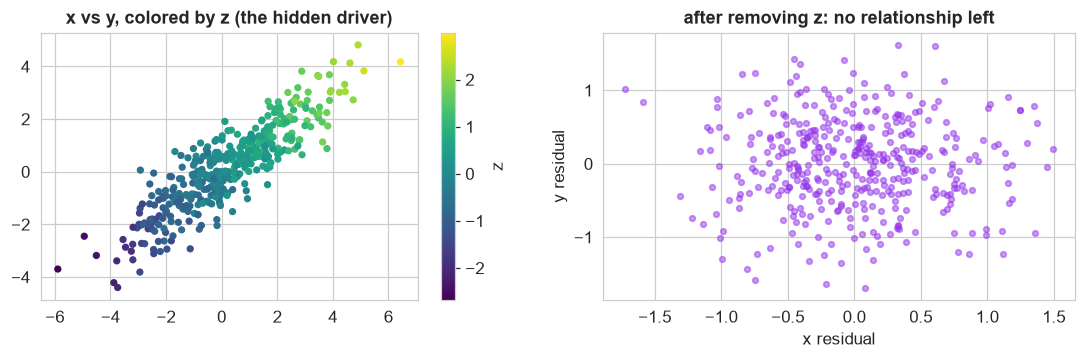

In [3]:
z=rng.normal(0,1,400)                       # the hidden common cause
x=2.0*z + rng.normal(0,0.6,400)             # z drives x
y=1.5*z + rng.normal(0,0.6,400)             # z drives y (NOT x)
print(f"raw corr(x, y)           = {stats.pearsonr(x,y)[0]:.2f}   <- strong, but spurious")
def resid(v,w): return sm.OLS(v, sm.add_constant(w)).fit().resid
print(f"partial corr(x, y | z)   = {stats.pearsonr(resid(x,z), resid(y,z))[0]:.2f}   <- collapses once z is held constant")
fig,ax=plt.subplots(1,2,figsize=(10,3.4))
sc=ax[0].scatter(x,y,c=z,cmap="viridis",s=14); ax[0].set_title("x vs y, colored by z (the hidden driver)"); plt.colorbar(sc,ax=ax[0],label="z")
ax[1].scatter(resid(x,z),resid(y,z),s=14,color=PUR,alpha=0.5); ax[1].set_title("after removing z: no relationship left")
ax[1].set_xlabel("x residual"); ax[1].set_ylabel("y residual"); plt.tight_layout(); plt.show()

Color the points by z and the illusion is obvious: the "relationship" is just z sliding both variables together. Strip z out (right panel) and the cloud goes round, the partial correlation near 0 is the statistical fingerprint of a <strong>confounder</strong>.

<div style="background:#faf5ff;border-left:5px solid #9333ea;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7e22ce;letter-spacing:1px">DEMO 3 · REVERSE CAUSATION & SPURIOUS BY CHANCE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Two more ways a correlation lies</div>
<div style="color:#4a5578;margin-top:6px">REVERSE causation: the arrow points the other way (do police cause crime, or crime cause police?). SPURIOUS by chance: test enough unrelated pairs and some will correlate strongly by luck, the multiple-comparisons trap from Chapter 75.</div>
</div>

In [4]:
# spurious-by-chance: 1000 pairs of PURE NOISE, how strong does the luckiest correlation get?
best=max(abs(np.corrcoef(rng.normal(0,1,30), rng.normal(0,1,30))[0,1]) for _ in range(1000))
print(f"1000 unrelated 30-point pairs: the strongest |r| by pure luck = {best:.2f}")
print("With enough comparisons, a strong correlation will appear from nothing -> demand a plausible mechanism.")

1000 unrelated 30-point pairs: the strongest |r| by pure luck = 0.63
With enough comparisons, a strong correlation will appear from nothing -> demand a plausible mechanism.


Small samples and many comparisons breed impressive-looking correlations from noise. The defenses are the same throughout science: ask <em>which direction is plausible?</em>, look for a <em>mechanism</em>, and reserve causal claims for <strong>randomized experiments</strong> (Chapter 65) or careful causal inference.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">REAL-WORLD EXAMPLE · ICE CREAM, DROWNINGS & TEMPERATURE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A textbook confounder, in real data</div>
<div style="color:#4a5578;margin-top:6px"></div>
</div>

Daily records show ice-cream sales and drownings rise together (`ch91_confounding.xlsx`). Does ice cream cause drownings? We explore, measure the raw correlation, then control for temperature, the lurking common cause.

In [5]:
try:    d = pd.read_excel("../../data/ch91_confounding.xlsx", sheet_name="Days")
except FileNotFoundError: d = pd.read_excel(BASE+"ch91_confounding.xlsx", sheet_name="Days")
# EXPLORE FIRST: shape, missing, and the suspicious raw correlation
print("shape:", d.shape, "| missing:", d.isna().sum().sum())
print(d[["temperature_f","ice_cream_sales","drownings"]].describe().round(1).T[["mean","std","min","max"]])
print(f"\nraw corr(ice_cream_sales, drownings) = {d.ice_cream_sales.corr(d.drownings):.2f}  (alarming, if taken at face value)")

shape: (200, 5) | missing: 0
                  mean    std   min    max
temperature_f     75.4   12.4  42.0  102.0
ice_cream_sales  280.3  105.0  11.0  540.0
drownings          5.6    3.0   0.0   14.0

raw corr(ice_cream_sales, drownings) = 0.58  (alarming, if taken at face value)


corr(temperature, ice_cream) = 0.87
corr(temperature, drownings) = 0.68

PARTIAL corr(ice_cream, drownings | temperature) = -0.03  -> the link vanishes!


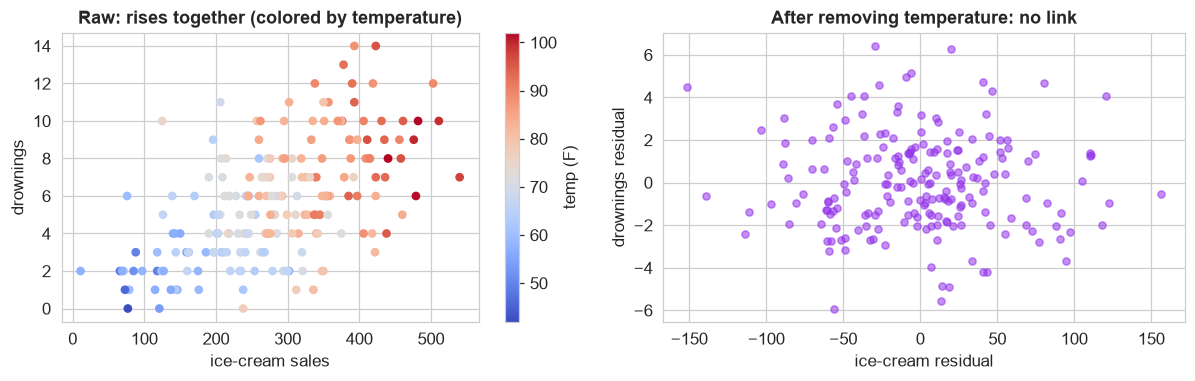

In [6]:
# temperature is correlated with BOTH -> the prime suspect for confounding
print(f"corr(temperature, ice_cream) = {d.temperature_f.corr(d.ice_cream_sales):.2f}")
print(f"corr(temperature, drownings) = {d.temperature_f.corr(d.drownings):.2f}")
def resid(v): return sm.OLS(d[v], sm.add_constant(d.temperature_f)).fit().resid
pc=stats.pearsonr(resid("ice_cream_sales"), resid("drownings"))[0]
print(f"\nPARTIAL corr(ice_cream, drownings | temperature) = {pc:.2f}  -> the link vanishes!")
fig,ax=plt.subplots(1,2,figsize=(11,3.6))
sc=ax[0].scatter(d.ice_cream_sales,d.drownings,c=d.temperature_f,cmap="coolwarm",s=22)
ax[0].set_xlabel("ice-cream sales"); ax[0].set_ylabel("drownings"); ax[0].set_title("Raw: rises together (colored by temperature)")
plt.colorbar(sc,ax=ax[0],label="temp (F)")
ax[1].scatter(resid("ice_cream_sales"),resid("drownings"),s=22,color=PUR,alpha=0.55)
ax[1].set_xlabel("ice-cream residual"); ax[1].set_ylabel("drownings residual"); ax[1].set_title("After removing temperature: no link")
plt.tight_layout(); plt.show()

The raw correlation is about <strong>0.58</strong>, but the color tells the truth: hot days (red) sit top-right, cold days (blue) bottom-left. Temperature drives both, more ice cream AND more swimming, hence more drownings. Control for it and the <strong>partial correlation collapses to about &#8722;0.03</strong>: ice cream and drownings have no direct link at all. Banning ice cream would not save a single swimmer; the cause is the heat.

<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Correlation vs causation</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">A correlation has four explanations: x&#8594;y, y&#8594;x, a confounder z&#8594;both, or coincidence. The data cannot distinguish them; only randomized experiments or causal reasoning can. Confounding is caught by a PARTIAL correlation (control for z, the link collapses), as with ice cream and drownings (raw 0.58 &#8594; partial &#8722;0.03 once temperature is held constant). Watch for reverse causation and spurious-by-chance correlations too. This completes the correlation Part; next, regression turns these relationships into predictions.</div></div>

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>